# American Options

American options give the holder the right but not the obligation to purchase(call)/sell(put) the underlying asset at any time on or before the option maturity. With the early exercise feature, the pricing of american option no longer relies solely on the conditional expectation of terminal payoff, but also the conditional expectation of every preceding time points.

In [ ]:
# Libraries and path
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))
FIGURE_DIR = Path.cwd().parent / "docs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Core
from derivlab.core.enums import OptionKind

# Product and Model
from derivlab import AmericanOption, BlackScholesModel, EuropeanOption, MarketParams

# Analytical lower bound
from derivlab.pricers.analytic.black_scholes import black_scholes_price

# Monte Carlo
from derivlab.pricers.monte_carlo.lsmc import LSMCConfig, LSMCPricer

# PDE
from derivlab.pricers.pde.black_scholes_pde import BlackScholesPDEPricer
from derivlab.pricers.pde.grids import GridConfig

## Setup


In [2]:
# Black-Scholes framework
market = MarketParams(spot=100, rate=0.05, dividend=0.0, volatility=0.2)
model = BlackScholesModel(market)
american_put = AmericanOption(OptionKind.PUT, strike=100, maturity=1.0)
european_put = EuropeanOption(OptionKind.PUT, strike=100, maturity=1.0)

## European Lower Bound

The European put is not an American benchmark price, but it is a lower bound. The American early-exercise premium is measured relative to this value.


In [3]:
european_reference = black_scholes_price(model, european_put)

lower_bound_result = pd.DataFrame(
    {
        "Method": "European Black-Scholes lower bound",
        "Price": european_reference,
    },
    index=[0],
)
lower_bound_result

,Method,Price
0,European Black-Scholes lower bound,5.573526


## Finite Difference PDE

The PDE for American option is constructed in the same manner as for European option with an extra step of comparing the value of termination vs continuation at each monitoring date. 


In [4]:
N = [100, 150, 200, 250, 400, 600, 800, 1000]
implicit_pde_results = []
crank_nicolson_pde_results = []

for n in N:
    implicit_result = BlackScholesPDEPricer(
        GridConfig(s_max=300, n_space=n, n_time=n, theta=1.0)
    ).price(model, american_put)

    crank_nicolson_result = BlackScholesPDEPricer(
        GridConfig(s_max=300, n_space=n, n_time=n, theta=0.5)
    ).price(model, american_put)

    implicit_pde_results.extend([{
                                    "PDE method": "Implicit",
                                    "No. of space steps": n,
                                    "No. of time steps": n,
                                    "Price": implicit_result.price,
                                    "Early exercise premium": implicit_result.price - european_reference,
                                    "Run time (s)": implicit_result.runtime,
                                }])

    crank_nicolson_pde_results.extend([{
                                        "PDE method": "Crank-Nicolson",
                                        "No. of space steps": n,
                                        "No. of time steps": n,
                                        "Price": crank_nicolson_result.price,
                                        "Early exercise premium": crank_nicolson_result.price - european_reference,
                                        "Run time (s)": crank_nicolson_result.runtime,
                                    }])

pde_implicit_result = implicit_result
pde_cn_result = crank_nicolson_result

implicit_pde = pd.DataFrame(implicit_pde_results)
crank_nicolson_pde = pd.DataFrame(crank_nicolson_pde_results)


In [5]:
display(implicit_pde)
display(crank_nicolson_pde)

,PDE method,No. of space steps,No. of time steps,Price,Early exercise premium,Run time (s)
0,Implicit,100,100,6.077924,0.504398,0.012526
1,Implicit,150,150,6.063618,0.490092,0.018494
2,Implicit,200,200,6.081006,0.507480,0.034879
3,Implicit,250,250,6.082323,0.508797,0.054420
4,Implicit,400,400,6.084820,0.511294,0.133903
5,Implicit,600,600,6.085492,0.511966,0.307916
6,Implicit,800,800,6.087358,0.513832,0.494124
7,Implicit,1000,1000,6.087918,0.514392,0.788082


,PDE method,No. of space steps,No. of time steps,Price,Early exercise premium,Run time (s)
0,Crank-Nicolson,100,100,6.094949,0.521423,0.009067
1,Crank-Nicolson,150,150,6.075621,0.502095,0.018222
2,Crank-Nicolson,200,200,6.090025,0.516499,0.033377
3,Crank-Nicolson,250,250,6.089701,0.516175,0.055980
4,Crank-Nicolson,400,400,6.089546,0.516020,0.136036
5,Crank-Nicolson,600,600,6.088714,0.515188,0.305130
6,Crank-Nicolson,800,800,6.089796,0.516270,0.477229
7,Crank-Nicolson,1000,1000,6.089884,0.516358,0.727677


## LSMC

Longstaff-Schwartz estimates continuation value by regression on simulated paths, then decides whether to continue or exercise at each exercise date.


In [6]:
M = [10_000, 50_000, 100_000]
D = [2, 3]

lsmc_results = []

for m in M:
        for d in D:
            lsmc_config = LSMCConfig(n_paths=m, n_steps=252, seed=42, polynomial_degree=d)
            lsmc_result = LSMCPricer(lsmc_config).price(model, american_put)

            lsmc_results.extend([{
                                    "MC method": "LSMC",
                                    "No. of paths": m,
                                    "No. of exercise steps": lsmc_config.n_steps,
                                    "Polynomial degree": lsmc_config.polynomial_degree,
                                    "Price": lsmc_result.price,
                                    "Standard Error": lsmc_result.stderr,
                                    "Early exercise premium": lsmc_result.price - european_reference,
                                    "Run time (s)": lsmc_result.runtime,
                                }])

lsmc_full = pd.DataFrame(lsmc_results)


In [7]:
display(lsmc_full)

,MC method,No. of paths,No. of exercise steps,Polynomial degree,Price,Standard Error,Early exercise premium,Run time (s)
0,LSMC,10000,252,2,6.019951,0.069285,0.446425,0.184950
1,LSMC,10000,252,3,6.040866,0.068581,0.467340,0.180762
2,LSMC,50000,252,2,6.037621,0.031407,0.464095,1.475748
3,LSMC,50000,252,3,6.072176,0.031683,0.498650,1.534766
4,LSMC,100000,252,2,6.055451,0.022281,0.481925,2.478729
5,LSMC,100000,252,3,6.088266,0.022531,0.514740,2.695684


## Variance Reduction For American Options

Variance reduction for American options is more delicate than for European options because LSMC does not estimate a fixed terminal payoff. It estimates an exercise policy and then prices the cashflows generated by that policy.

For a European option, the Monte Carlo target is simply:

$$
V_0 = e^{-rT} \mathbb{E}[h(S_T)].
$$

Once the paths are simulated, the payoff functional is fixed. Variance reduction methods such as antithetic variates or control variates act directly on the random payoff sample.

For an American option, the target is an optimal stopping problem (i.e., when to exercise):

$$
V_0 = \sup_{\tau \leq T} \mathbb{E}[e^{-r\tau} h(S_\tau)].
$$

In LSMC, the stopping rule is not known in advance. It is estimated by backward induction. At each exercise date, the algorithm compares immediate exercise value with an estimated continuation value:

$$
h(S_t) \quad \text{versus} \quad \widehat{\mathbb{E}}[\text{discounted future cashflow} \mid S_t].
$$

This means simulation noise affects two objects: the cashflow samples and the estimated exercise boundary. A variance reduction method can therefore change both the value estimate and the exercise policy used to produce that estimate.

## Result Plots


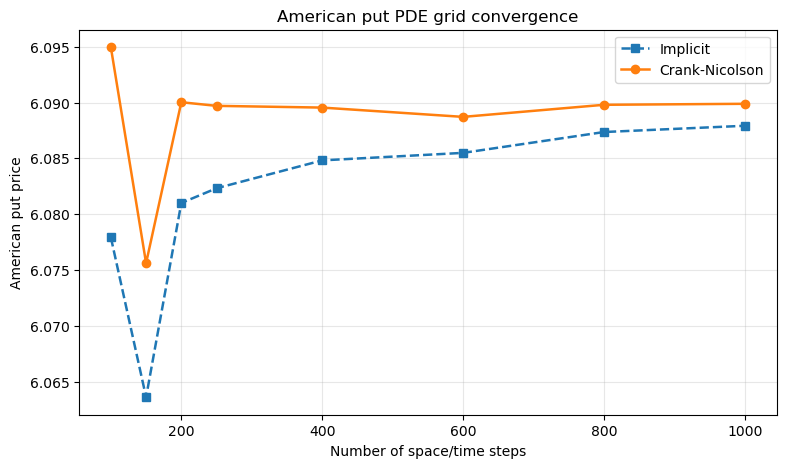

In [14]:
pde_plot_data = [
    ("Implicit", implicit_pde, "s", "--"),
    ("Crank-Nicolson", crank_nicolson_pde, "o", "-"),
]

plt.figure(figsize=(9, 5))
#plt.axhline(european_reference, color="black", linestyle=":", linewidth=1.5, label="European put lower bound")

for label, df, marker, linestyle in pde_plot_data:
    plt.plot(
        df["No. of space steps"],
        df["Price"],
        marker=marker,
        linestyle=linestyle,
        linewidth=1.8,
        label=label,
    )

plt.xlabel("Number of space/time steps")
plt.ylabel("American put price")
plt.title("American put PDE grid convergence")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIGURE_DIR / "american_pde_grid_convergence.png", dpi=200, bbox_inches="tight")
plt.show()


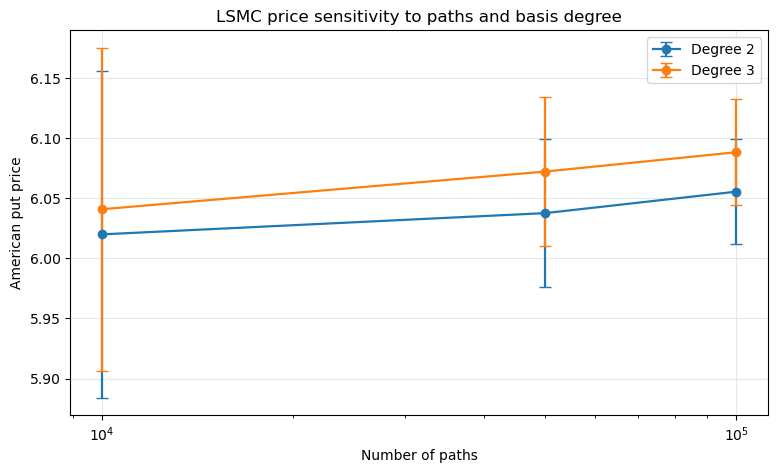

In [15]:
plt.figure(figsize=(9, 5))

for degree, group in lsmc_full.groupby("Polynomial degree"):
    plt.errorbar(
        group["No. of paths"],
        group["Price"],
        yerr=1.96 * group["Standard Error"],
        marker="o",
        capsize=4,
        linewidth=1.6,
        label=f"Degree {degree}",
    )

#plt.axhline(european_reference, color="black", linestyle=":", linewidth=1.5, label="European put lower bound")
plt.xscale("log")
plt.xlabel("Number of paths")
plt.ylabel("American put price")
plt.title("LSMC price sensitivity to paths and basis degree")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIGURE_DIR / "american_lsmc_price_sensitivity.png", dpi=200, bbox_inches="tight")
plt.show()


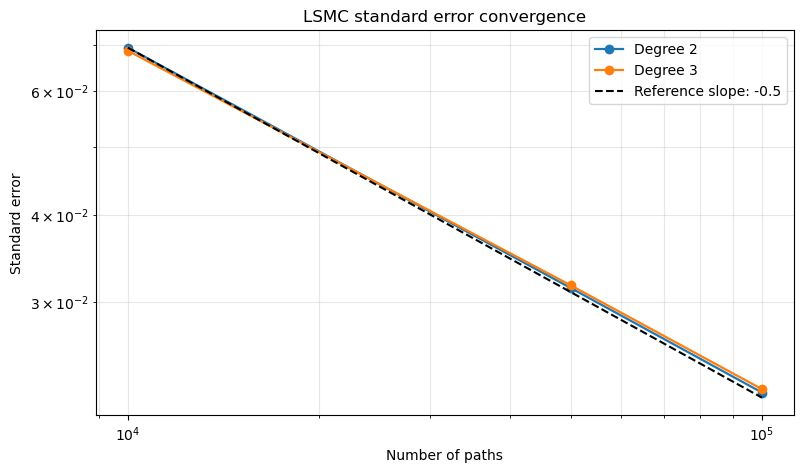

In [16]:
plt.figure(figsize=(9, 5))

for degree, group in lsmc_full.groupby("Polynomial degree"):
    plt.plot(
        group["No. of paths"],
        group["Standard Error"],
        marker="o",
        linewidth=1.6,
        label=f"Degree {degree}",
    )

reference_group = lsmc_full[lsmc_full["Polynomial degree"] == lsmc_full["Polynomial degree"].min()]
reference_paths = reference_group["No. of paths"]
reference_stderr = reference_group["Standard Error"].iloc[0] * (reference_paths.iloc[0] / reference_paths) ** 0.5
plt.plot(reference_paths, reference_stderr, color="black", linestyle="--", linewidth=1.5, label="Reference slope: -0.5")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of paths")
plt.ylabel("Standard error")
plt.title("LSMC standard error convergence")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.savefig(FIGURE_DIR / "american_lsmc_standard_error.png", dpi=200, bbox_inches="tight")
plt.show()
